# (06) fit w/ grad — (T, beta) = (10, 12.0)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:3```

**Motivation**: <br>



In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 10
cfg_vae['n_iters'] = 1

cfg_vae['init_scale'] = 1e-2
cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 12.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.01, 'seq_len': 10, 'n_iters': 1, 'track_stats': True}

Trainer:
{'batch_size': 200, 'epochs': 300, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 12.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-10×1_b-1_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(12:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_09,18:32)

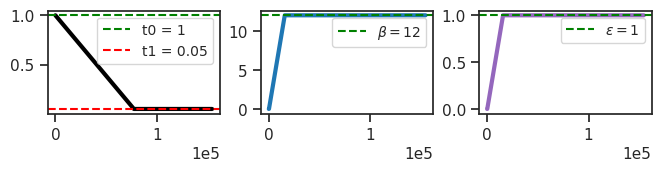

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
cm = 'bias-local_lr-global'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 249.432092: 100%|████| 300/300 [2:46:10<00:00, 33.23s/it]


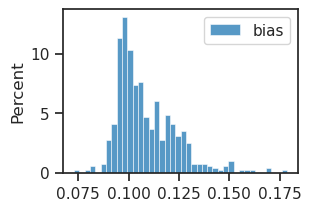

In [8]:
fig, ax = create_figure()

kws = dict(bins=40, stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

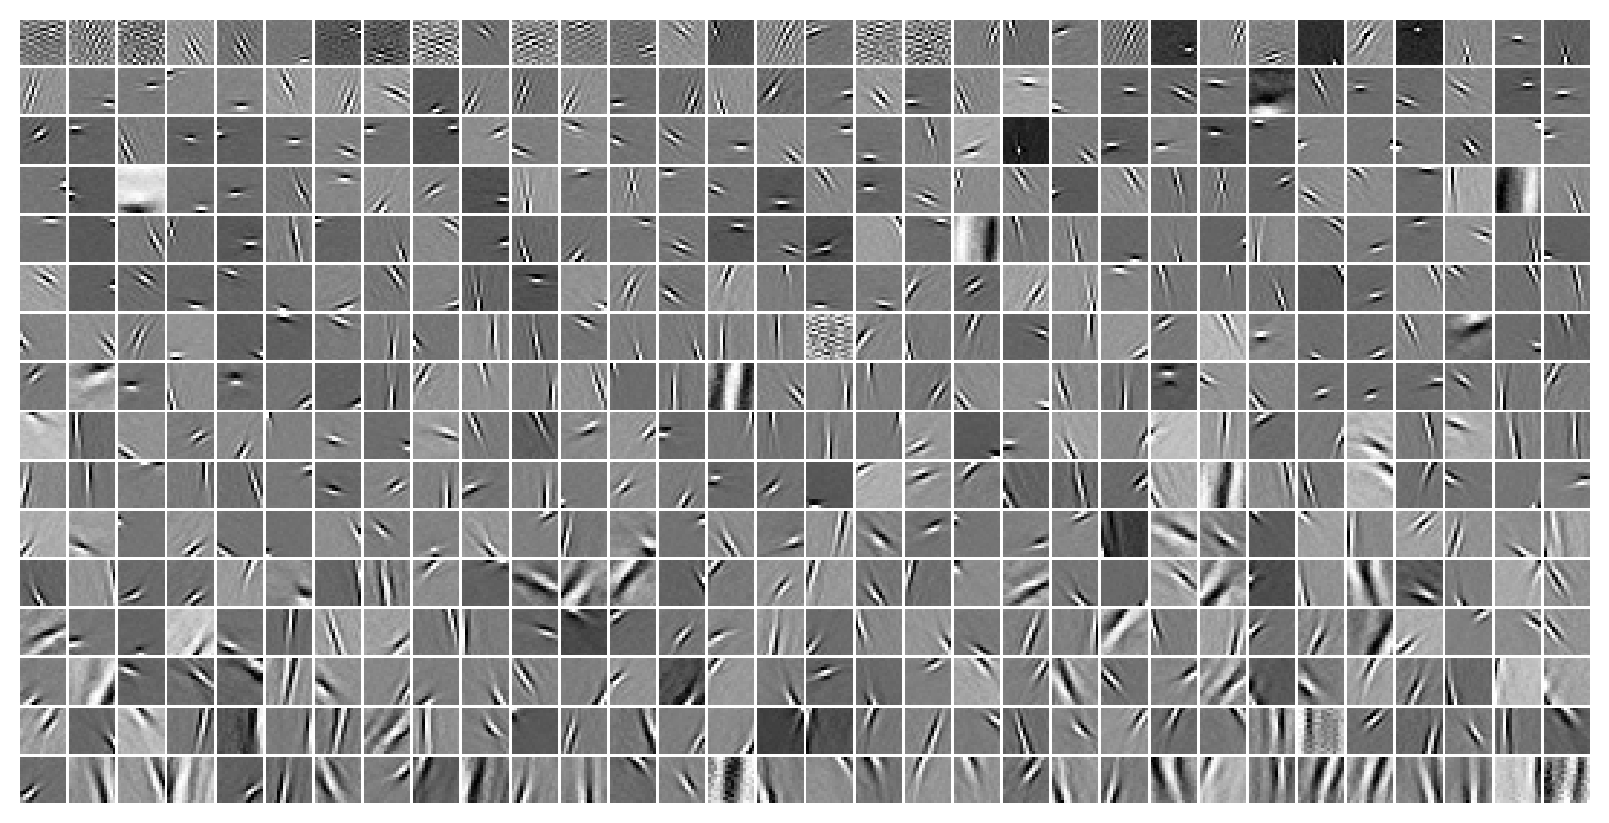

In [9]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

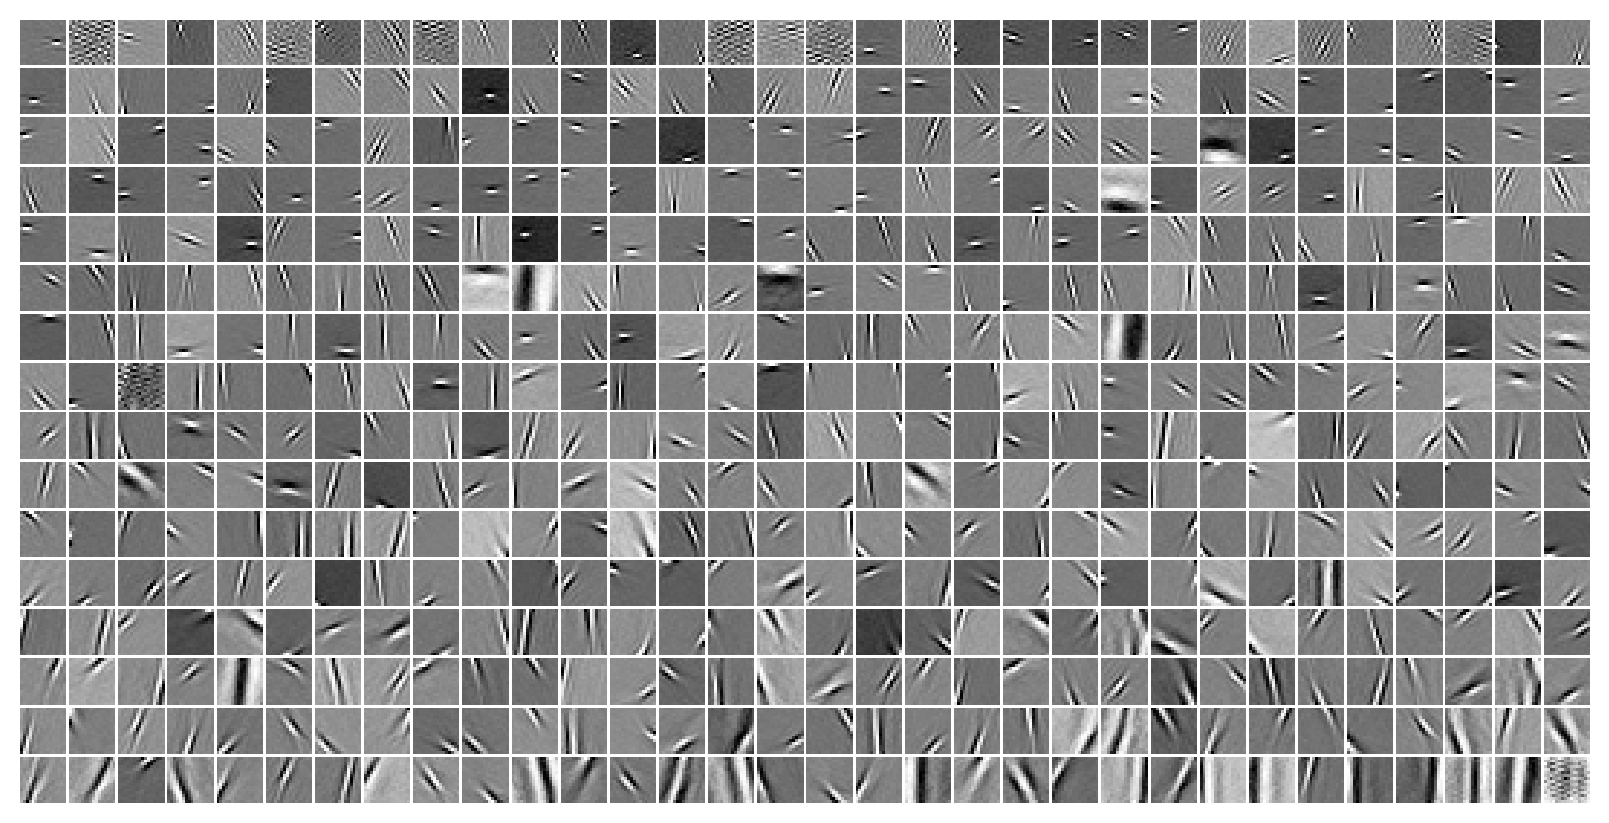

In [9]:
### Was: batch_size, epochs = 500, 600

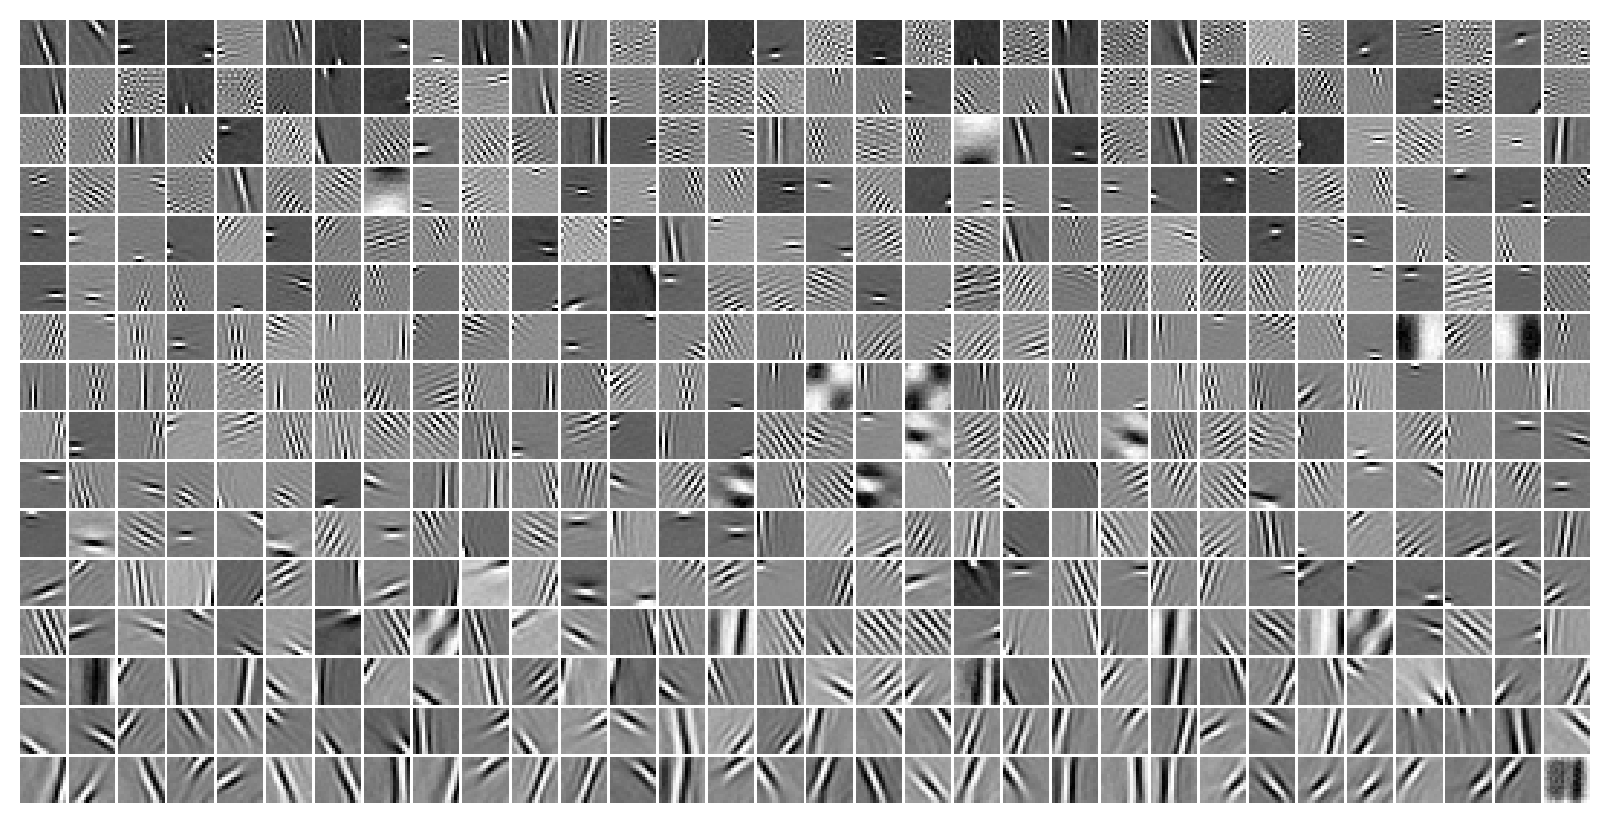

In [12]:
### Was: beta = 12.0, both local

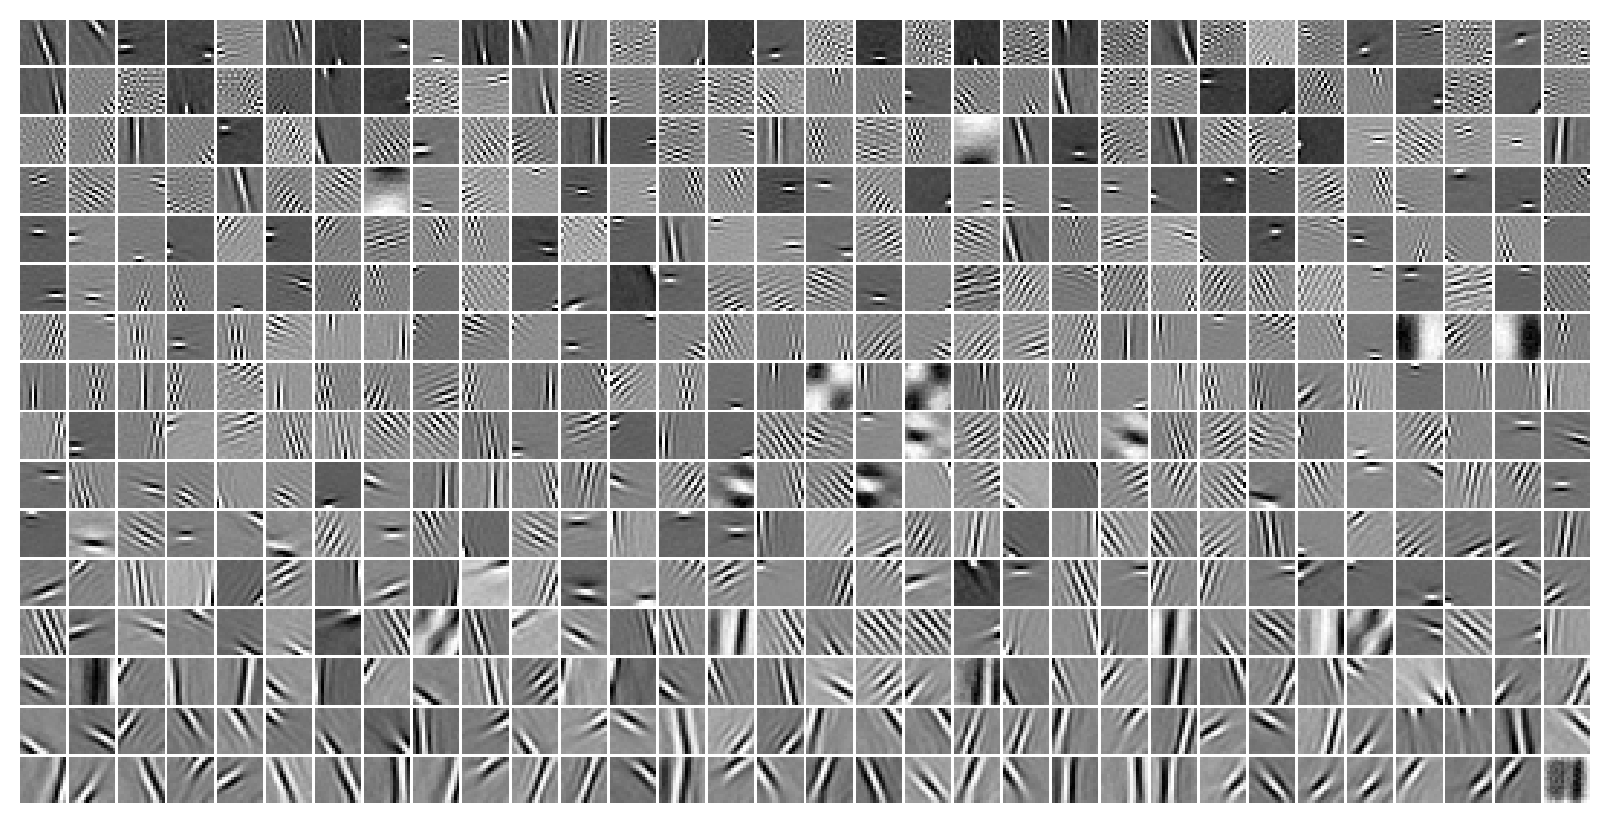

In [17]:
lr = tonp(tr.model.layer.log_lr.exp().squeeze())
tr.model.show(order=np.argsort(u0));

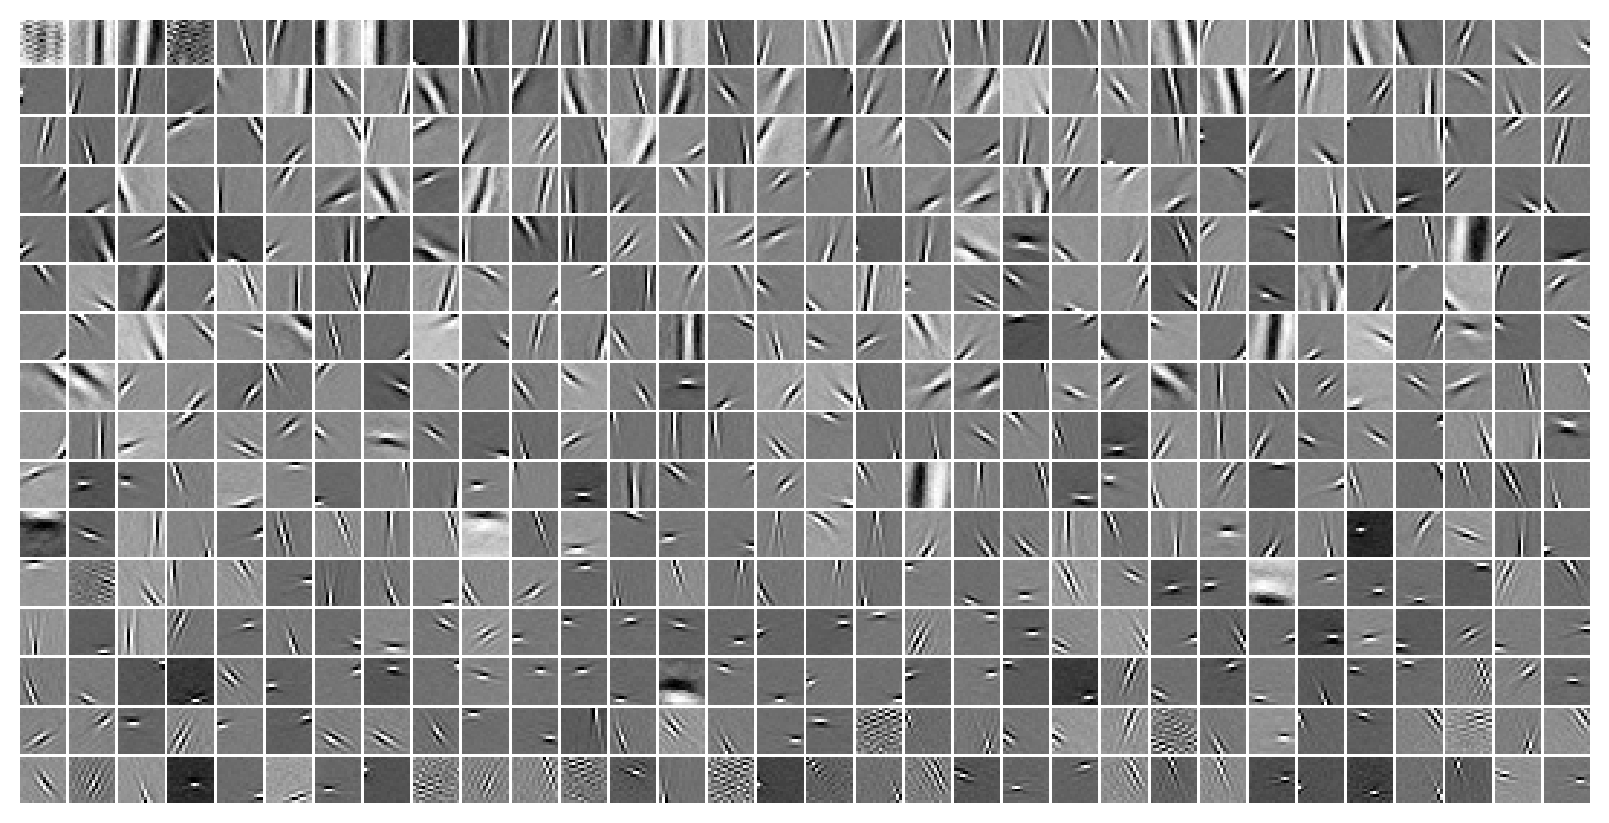

In [10]:
bias = tonp(tr.model.layer.log_bias.squeeze())
tr.model.show(order=np.argsort(bias));

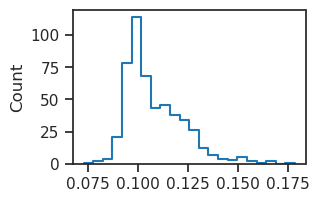

In [10]:
histplot(tr.model.layer.log_bias.squeeze().exp());

In [11]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'recon', 'samples', 'conditional']

CPU times: user 3.31 s, sys: 150 ms, total: 3.46 s
Wall time: 3.46 s


[0.8786258101463318,
 0.8788164854049683,
 0.8784385919570923,
 0.8780416250228882,
 0.8780028223991394]

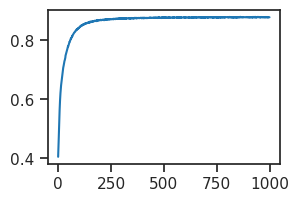

In [12]:
from analysis.sparse import sparse_score

t = 0
lifetime, population = [], []
for t in range(1000):
    life, popu, _ = sparse_score(output['samples'][:, t, :])
    lifetime.append(life.mean().item())
    population.append(popu.mean().item())


plt.plot(lifetime);
lifetime[-5:]

tensor([32.8635, 32.7167, 32.9269, 32.7184, 32.2444], device='cuda:3')

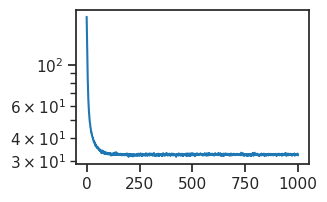

In [13]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

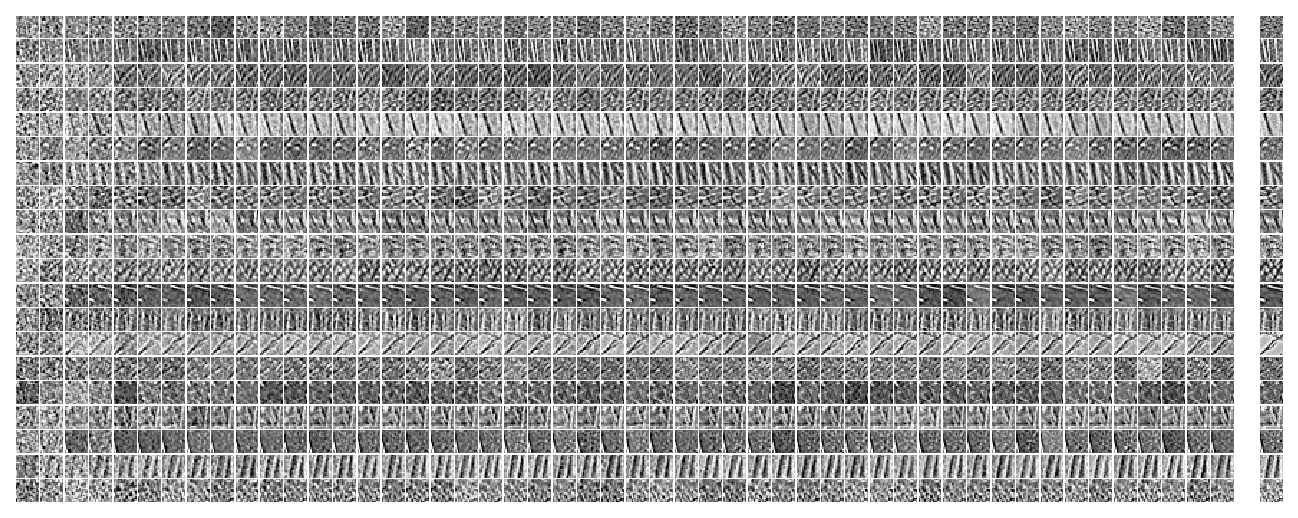

In [14]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

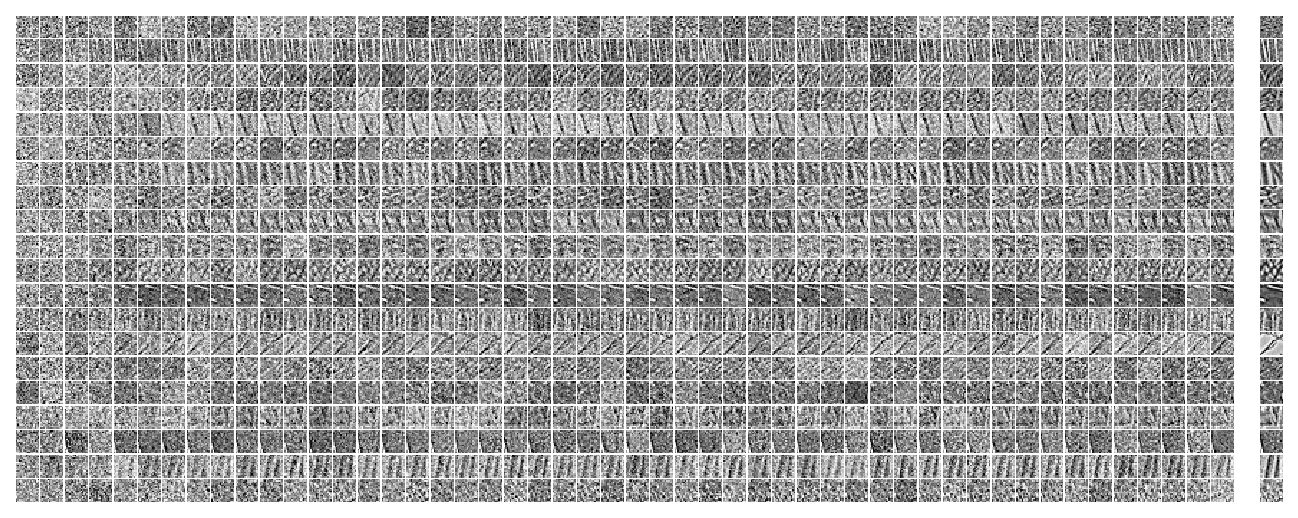

In [15]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

tensor([0.7879, 0.7857, 0.8043, 0.7703, 0.7955], device='cuda:3')

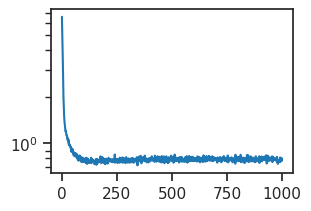

In [16]:
fig, ax = create_figure()

x2p = output['loss_kl'].sum(-1).mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([159.0848, 158.8978, 159.1693, 158.9089, 158.3103], device='cuda:3')

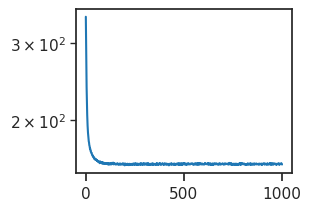

In [17]:
fig, ax = create_figure()

x2p = output['loss_recon'].mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([32.8635, 32.7167, 32.9269, 32.7184, 32.2444], device='cuda:3')

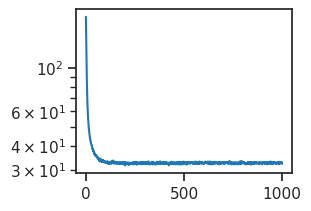

In [18]:
fig, ax = create_figure()

x2p = mse.mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]